# MegaDetector v1000 Endpoint Performance Analysis

This notebook analyzes timing data from CloudWatch logs for the deployed endpoints.

In [76]:
import boto3
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## Configuration

In [81]:
# Endpoint configuration - add multiple endpoints to compare
endpoints = [
    'mdv1000-0-0-redwood-concurrency-20',
    'mdv1000-0-0-redwood-concurrency-80',
    'mdv5a-concurrency-80',
    'mdv5a-concurrency-20'
]

profile_name = 'animl'
region = 'us-west-2'

# Time range to analyze
hours_back = 168  # Look back this many hours

## Fetch Logs

In [82]:
# Initialize boto3 client
session = boto3.Session(profile_name=profile_name, region_name=region)
logs = session.client('logs')

start_time = int((datetime.now() - timedelta(hours=hours_back)).timestamp() * 1000)

# Fetch logs for all endpoints
all_endpoint_data = {}

for endpoint_name in endpoints:
    log_group = f"/aws/sagemaker/Endpoints/{endpoint_name}"
    print(f"\nFetching logs for {endpoint_name}...")
    
    try:
        # Get log streams
        streams = logs.describe_log_streams(
            logGroupName=log_group,
            orderBy='LastEventTime',
            descending=True,
            limit=50
        )
        
        # Fetch events from streams
        events = []
        for stream in streams['logStreams']:
            if stream['lastEventTimestamp'] < start_time:
                continue
            
            response = logs.get_log_events(
                logGroupName=log_group,
                logStreamName=stream['logStreamName'],
                startTime=start_time,
                startFromHead=False
            )
            events.extend(response['events'])
        
        all_endpoint_data[endpoint_name] = events
        print(f"  Found {len(events)} events")
        
    except Exception as e:
        print(f"  Error fetching logs: {e}")
        all_endpoint_data[endpoint_name] = []


Fetching logs for mdv1000-0-0-redwood-concurrency-20...
  Found 426 events

Fetching logs for mdv1000-0-0-redwood-concurrency-80...
  Found 160 events

Fetching logs for mdv5a-concurrency-80...
  Found 6938 events

Fetching logs for mdv5a-concurrency-20...
  Found 8412 events


## Parse Timing Data

In [83]:
# Parse timing information from log messages
# Pattern for mdv1000 (FastAPI format)
pattern_mdv1000 = r"Request completed in ([\d.]+)s \(decode: ([\d.]+)s, inference: ([\d.]+)s, format: ([\d.]+)s\) - (\d+) detections"

# Patterns for mdv5a (TorchServe format)
pattern_preprocess = r"XXXXX  Preprocess time:  ([\d.]+)"
pattern_inference = r"XXXXX  Inference time:  ([\d.]+)"
pattern_postprocess = r"XXXXX  Postprocessing time:  ([\d.]+)"

all_dfs = {}

for endpoint_name, events in all_endpoint_data.items():
    timings = []
    
    # Try mdv1000 format first
    for event in events:
        match = re.search(pattern_mdv1000, event['message'])
        if match:
            timings.append({
                'timestamp': datetime.fromtimestamp(event['timestamp'] / 1000),
                'total': float(match.group(1)),
                'decode': float(match.group(2)),
                'inference': float(match.group(3)),
                'format': float(match.group(4)),
                'detections': int(match.group(5)),
                'endpoint': endpoint_name
            })
    
    # If no mdv1000 matches, try mdv5a format (TorchServe)
    if len(timings) == 0:
        # Group events by timestamp proximity (within 10 seconds = same request)
        i = 0
        while i < len(events):
            event = events[i]
            
            # Look for preprocess time
            match_pre = re.search(pattern_preprocess, event['message'])
            if match_pre:
                preprocess_time = float(match_pre.group(1))
                timestamp = datetime.fromtimestamp(event['timestamp'] / 1000)
                
                # Look ahead for inference and postprocess within next 10 events
                inference_time = None
                postprocess_time = None
                
                for j in range(i+1, min(i+10, len(events))):
                    match_inf = re.search(pattern_inference, events[j]['message'])
                    if match_inf:
                        inference_time = float(match_inf.group(1))
                    
                    match_post = re.search(pattern_postprocess, events[j]['message'])
                    if match_post:
                        postprocess_time = float(match_post.group(1))
                        break
                
                # If we found all three, add the timing
                if inference_time and postprocess_time:
                    total_time = preprocess_time + inference_time + postprocess_time
                    timings.append({
                        'timestamp': timestamp,
                        'total': total_time,
                        'decode': preprocess_time,
                        'inference': inference_time,
                        'format': postprocess_time,
                        'detections': 0,  # TorchServe doesn't log detection count
                        'endpoint': endpoint_name
                    })
            
            i += 1
    
    df = pd.DataFrame(timings)
    all_dfs[endpoint_name] = df
    print(f"{endpoint_name}: {len(df)} invocations")

# Combine all dataframes
non_empty_dfs = [df for df in all_dfs.values() if not df.empty]
df_combined = pd.concat(non_empty_dfs, ignore_index=True) if non_empty_dfs else pd.DataFrame()
print(f"\nTotal invocations across all endpoints: {len(df_combined)}")

mdv1000-0-0-redwood-concurrency-20: 18 invocations
mdv1000-0-0-redwood-concurrency-80: 15 invocations
mdv5a-concurrency-80: 145 invocations
mdv5a-concurrency-20: 258 invocations

Total invocations across all endpoints: 436


## Summary Statistics

In [84]:
if len(df_combined) > 0:
    print("=" * 80)
    print("ENDPOINT COMPARISON")
    print("=" * 80)
    
    for endpoint_name, df in all_dfs.items():
        if len(df) == 0:
            continue
            
        print(f"\n{'=' * 80}")
        print(f"ENDPOINT: {endpoint_name}")
        print(f"{'=' * 80}")
        print(f"Total Requests: {len(df)}")
        print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        print("\n" + "-" * 80)
        print("TIMING BREAKDOWN (seconds)")
        print("-" * 80)
        
        stats = df[['total', 'decode', 'inference', 'format']].describe()
        print(stats.round(3))
        
        print("\n" + "-" * 80)
        print("DETECTIONS")
        print("-" * 80)
        print(f"Average detections per image: {df['detections'].mean():.2f}")
        print(f"Min/Max detections: {df['detections'].min()} / {df['detections'].max()}")
    
    # Comparison table
    if len(endpoints) > 1:
        print(f"\n\n{'=' * 80}")
        print("COMPARISON SUMMARY")
        print(f"{'=' * 80}\n")
        
        comparison = pd.DataFrame({
            'Endpoint': [name for name in all_dfs.keys() if len(all_dfs[name]) > 0],
            'Requests': [len(df) for df in all_dfs.values() if len(df) > 0],
            'Avg Total (s)': [df['total'].mean() for df in all_dfs.values() if len(df) > 0],
            'Avg Inference (s)': [df['inference'].mean() for df in all_dfs.values() if len(df) > 0],
            'P50 Total (s)': [df['total'].median() for df in all_dfs.values() if len(df) > 0],
            'P95 Total (s)': [df['total'].quantile(0.95) for df in all_dfs.values() if len(df) > 0],
        })
        print(comparison.round(3).to_string(index=False))
else:
    print("No timing data found.")

ENDPOINT COMPARISON

ENDPOINT: mdv1000-0-0-redwood-concurrency-20
Total Requests: 18
Time Range: 2026-01-23 09:56:31.583000 to 2026-01-24 12:29:31.422000

--------------------------------------------------------------------------------
TIMING BREAKDOWN (seconds)
--------------------------------------------------------------------------------
        total  decode  inference  format
count  18.000  18.000     18.000    18.0
mean    4.040   0.044      3.995     0.0
std     0.748   0.007      0.747     0.0
min     3.106   0.036      3.055     0.0
25%     3.503   0.040      3.462     0.0
50%     3.808   0.040      3.770     0.0
75%     4.894   0.050      4.837     0.0
max     5.118   0.057      5.077     0.0

--------------------------------------------------------------------------------
DETECTIONS
--------------------------------------------------------------------------------
Average detections per image: 3.83
Min/Max detections: 3 / 4

ENDPOINT: mdv1000-0-0-redwood-concurrency-80
Total 

## Visualizations

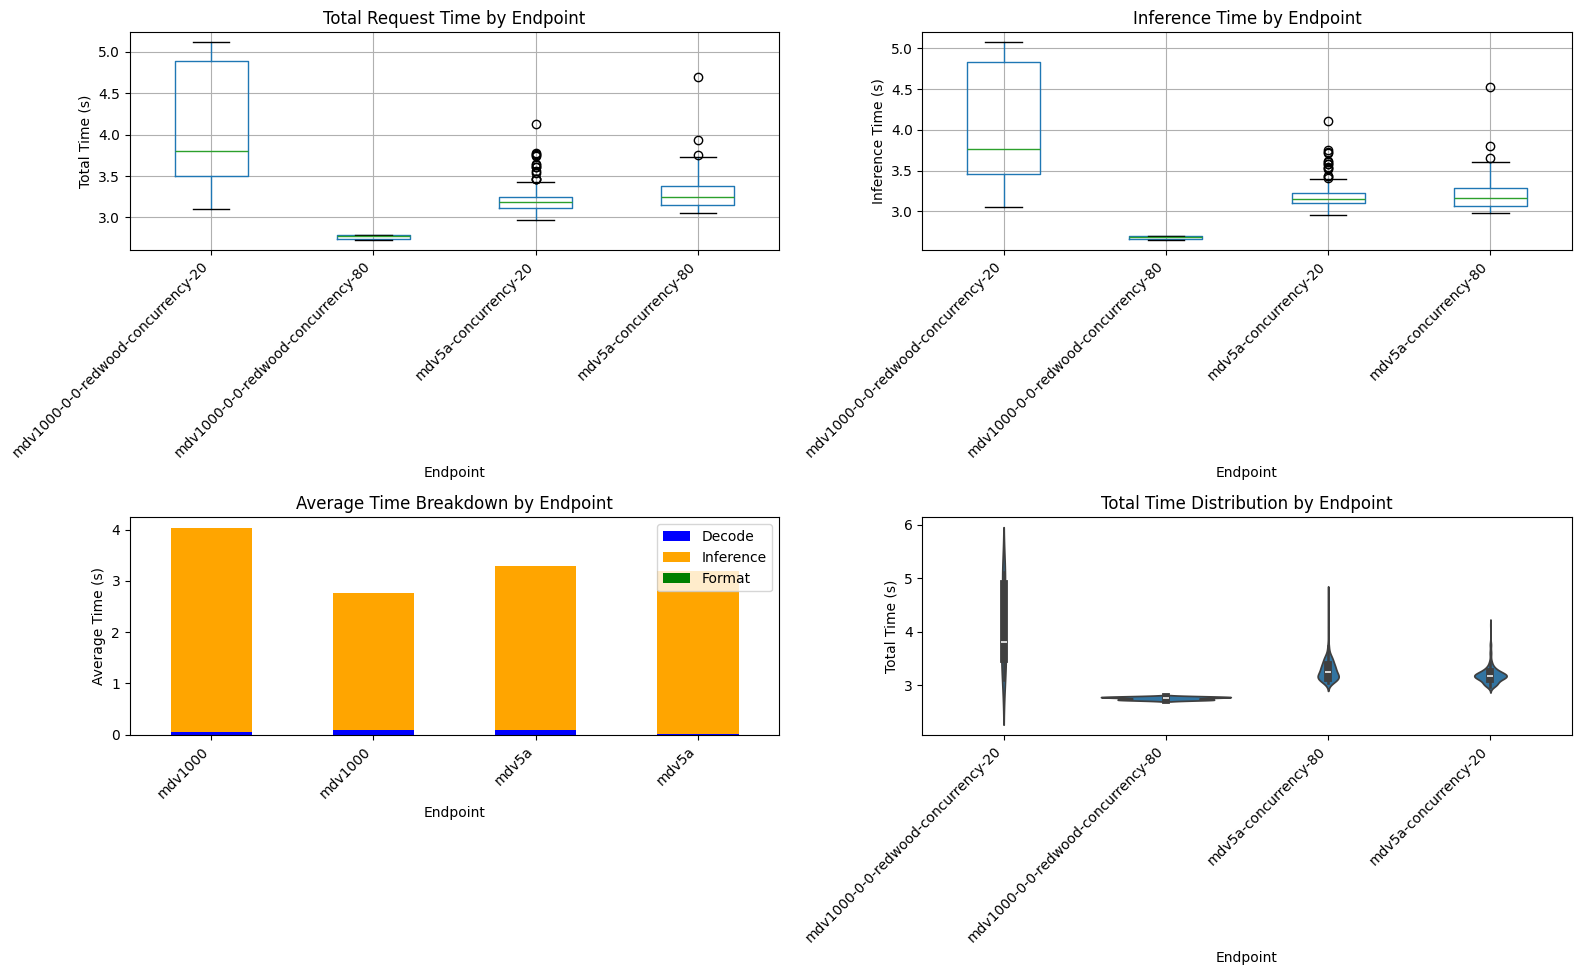

In [85]:
if len(df_combined) > 0:
    # Comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Total time comparison (box plot)
    df_combined.boxplot(column='total', by='endpoint', ax=axes[0, 0])
    axes[0, 0].set_xlabel('Endpoint')
    axes[0, 0].set_ylabel('Total Time (s)')
    axes[0, 0].set_title('Total Request Time by Endpoint')
    axes[0, 0].get_figure().suptitle('')  # Remove default title
    plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Inference time comparison (box plot)
    df_combined.boxplot(column='inference', by='endpoint', ax=axes[0, 1])
    axes[0, 1].set_xlabel('Endpoint')
    axes[0, 1].set_ylabel('Inference Time (s)')
    axes[0, 1].set_title('Inference Time by Endpoint')
    axes[0, 1].get_figure().suptitle('')
    plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Average time breakdown by endpoint
    breakdown_data = []
    for endpoint_name, df in all_dfs.items():
        if len(df) > 0:
            breakdown_data.append({
                'Endpoint': endpoint_name.split('-')[0],  # Shorten name
                'Decode': df['decode'].mean(),
                'Inference': df['inference'].mean(),
                'Format': df['format'].mean()
            })
    
    breakdown_df = pd.DataFrame(breakdown_data)
    breakdown_df.set_index('Endpoint')[['Decode', 'Inference', 'Format']].plot(
        kind='bar', stacked=True, ax=axes[1, 0], color=['blue', 'orange', 'green']
    )
    axes[1, 0].set_ylabel('Average Time (s)')
    axes[1, 0].set_title('Average Time Breakdown by Endpoint')
    axes[1, 0].legend(loc='upper right')
    plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Distribution comparison (violin plot)
    import seaborn as sns
    sns.violinplot(data=df_combined, x='endpoint', y='total', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Endpoint')
    axes[1, 1].set_ylabel('Total Time (s)')
    axes[1, 1].set_title('Total Time Distribution by Endpoint')
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize.")

## Time Series Analysis

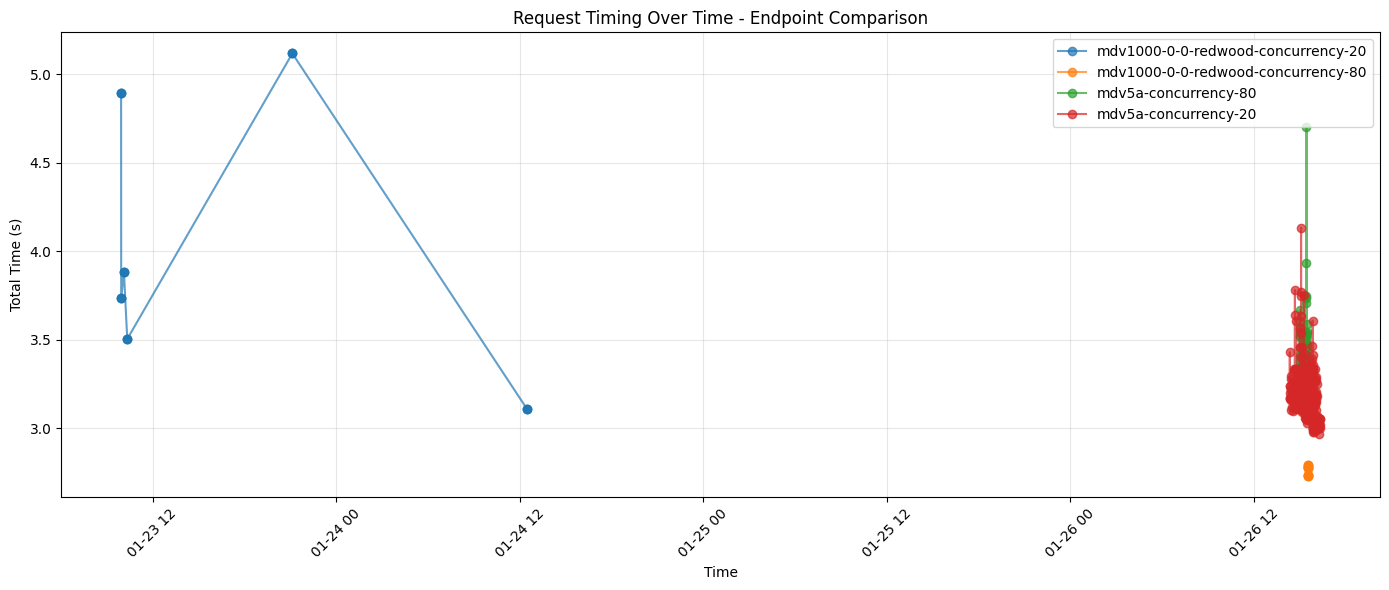

In [86]:
if len(df_combined) > 0 and len(endpoints) > 1:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for endpoint_name, df in all_dfs.items():
        if len(df) > 0:
            df_sorted = df.sort_values('timestamp')
            ax.plot(df_sorted['timestamp'], df_sorted['total'], 
                   marker='o', linestyle='-', alpha=0.7, label=endpoint_name)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Total Time (s)')
    ax.set_title('Request Timing Over Time - Endpoint Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
elif len(df_combined) > 0:
    # Single endpoint time series
    df = list(all_dfs.values())[0]
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df_sorted = df.sort_values('timestamp')
    ax.plot(df_sorted['timestamp'], df_sorted['total'], marker='o', linestyle='-', alpha=0.7, label='Total Time')
    ax.plot(df_sorted['timestamp'], df_sorted['inference'], marker='s', linestyle='-', alpha=0.7, label='Inference Time')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Time (s)')
    ax.set_title('Request Timing Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize.")

## Export Data

In [87]:
# Save data as JSON with structured sections
if len(df_combined) > 0:
    output_file = f"endpoint_comparison_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    
    # Build structured output
    output = {
        'summary': {},
        'comparison': [],
        'individual_results': {}
    }
    
    # Summary statistics for each endpoint
    for endpoint_name, df in all_dfs.items():
        if len(df) > 0:
            output['summary'][endpoint_name] = {
                'count': len(df),
                'average': {
                    'total': round(df['total'].mean(), 3),
                    'decode': round(df['decode'].mean(), 3),
                    'inference': round(df['inference'].mean(), 3),
                    'format': round(df['format'].mean(), 3),
                    'detections': round(df['detections'].mean(), 2)
                },
                'median': {
                    'total': round(df['total'].median(), 3),
                    'decode': round(df['decode'].median(), 3),
                    'inference': round(df['inference'].median(), 3),
                    'format': round(df['format'].median(), 3),
                    'detections': round(df['detections'].median(), 2)
                },
                'p95': {
                    'total': round(df['total'].quantile(0.95), 3),
                    'decode': round(df['decode'].quantile(0.95), 3),
                    'inference': round(df['inference'].quantile(0.95), 3),
                    'format': round(df['format'].quantile(0.95), 3),
                    'detections': round(df['detections'].quantile(0.95), 2)
                },
                'min': {
                    'total': round(df['total'].min(), 3),
                    'inference': round(df['inference'].min(), 3)
                },
                'max': {
                    'total': round(df['total'].max(), 3),
                    'inference': round(df['inference'].max(), 3)
                }
            }
    
    # Comparison table
    for endpoint_name, df in all_dfs.items():
        if len(df) > 0:
            output['comparison'].append({
                'endpoint': endpoint_name,
                'requests': len(df),
                'avg_total': round(df['total'].mean(), 3),
                'avg_inference': round(df['inference'].mean(), 3),
                'p50_total': round(df['total'].median(), 3),
                'p95_total': round(df['total'].quantile(0.95), 3)
            })
    
    # Individual results for each endpoint
    for endpoint_name, df in all_dfs.items():
        if len(df) > 0:
            output['individual_results'][endpoint_name] = df.to_dict('records')
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(output, f, indent=2, default=str)
    
    print(f"Data exported to {output_file}")
else:
    print("No data to export.")

Data exported to endpoint_comparison_20260126_162041.json
